# 1. Load Data

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('../../Data/student_performance_data.csv')
df.drop(columns=['overall_score','student_id'], inplace=True)
df

,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,grade
0,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,D
1,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,D
2,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,B
3,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,C
4,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,C
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Female,6.86,59.65,60.41,39.51,66.43,44.97,Yes,Yes,High School,8.56,C
9996,Male,2.60,83.62,62.45,48.96,81.40,45.11,Yes,Yes,Bachelor,4.21,C
9997,Female,1.46,95.40,67.08,51.51,87.58,65.49,Yes,No,Bachelor,4.72,B
9998,Female,7.15,78.24,97.73,46.51,75.49,61.21,No,No,Bachelor,5.28,B


In [2]:
df.columns

Index(['gender', 'study_hours_per_day', 'attendance_percentage',
       'assignment_score', 'midterm_score', 'final_exam_score',
       'participation_score', 'internet_access', 'extra_classes',
       'parent_education', 'sleep_hours', 'grade'],
      dtype='str')

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.2, random_state=42)

# 2. Data Preprocess

In [4]:
# ohe -> 'gender'
# ordinal -> 'parent_education'
# Label -> 'internet_access', 'extra_classes'
# scaling_transform -> 'study_hours_per_day', 'attendance_percentage','assignment_score', 'participation_score',midterm_score', 'final_exam_score', 'sleep_hours'



In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, PowerTransformer

scaling_transform = Pipeline([
    ("scl", StandardScaler()),
    ('power', PowerTransformer())
])

preprocessor = ColumnTransformer(transformers=[
    ("ohe", OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['gender']),
    ("ord", OrdinalEncoder(categories=[['High School','Bachelor','Master','PhD']]), ['parent_education']),
    ("ord_bin", OrdinalEncoder(), ['internet_access', 'extra_classes']),
    ("scaling_transform", scaling_transform, ['study_hours_per_day', 'attendance_percentage','assignment_score', 'midterm_score', 'final_exam_score','participation_score', 'sleep_hours'])
    
],remainder='passthrough')

In [6]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [7]:
lb = LabelEncoder()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

In [8]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# 3. Dataset and load

In [9]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features =  torch.tensor(features, dtype=torch.float32)
        self.labels =  torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [10]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

# 4. Build Model

In [11]:
import torch.nn as nn

class AnnModel(nn.Module):
    def __init__(self, X_train):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(X_train.shape[1], 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(32,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 5)
        )
        
    def forward(self, X_train):
        return self.network(X_train)

# 5. Train Model 

In [12]:
def train_model(learning_rate=0.1, epochs=100):
    model = AnnModel(X_train)
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    
    for epoch in range(epochs):
        
        model.train()
        epoch_loss = 0
        
        for batch_features, batch_labels in train_dataloader:
            
            # move to gpu
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            
            # forward propagation
            y_pred = model.forward(batch_features)
            
            # loss calculate
            loss = criterion(y_pred, batch_labels)
            
            # reinitialize gradient
            optimizer.zero_grad()
            
            # backpropagation
            loss.backward()

            # update weight and bias
            optimizer.step()
            
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_dataloader)
        losses.append(avg_loss)
        print(f"Epoch: {epoch+1}, Loss: {avg_loss}")    
        
    return model, losses

In [13]:
epochs = 100
model, losses = train_model(epochs=epochs, learning_rate=0.01)

Epoch: 1, Loss: 0.5202000532150268
Epoch: 2, Loss: 0.31206537729501727
Epoch: 3, Loss: 0.28156658470630647
Epoch: 4, Loss: 0.2608509945869446
Epoch: 5, Loss: 0.2591324373483658
Epoch: 6, Loss: 0.2566067887544632
Epoch: 7, Loss: 0.2500914703607559
Epoch: 8, Loss: 0.25123325556516646
Epoch: 9, Loss: 0.2400619539618492
Epoch: 10, Loss: 0.25755202734470367
Epoch: 11, Loss: 0.23991099733114243
Epoch: 12, Loss: 0.22723514300584793
Epoch: 13, Loss: 0.24276500976085663
Epoch: 14, Loss: 0.26623455768823623
Epoch: 15, Loss: 0.23505978041887282
Epoch: 16, Loss: 0.24775674259662628
Epoch: 17, Loss: 0.23917739275097846
Epoch: 18, Loss: 0.250101477086544
Epoch: 19, Loss: 0.22168349015712738
Epoch: 20, Loss: 0.23049801909923553
Epoch: 21, Loss: 0.25164759969711303
Epoch: 22, Loss: 0.23571795892715455
Epoch: 23, Loss: 0.22896166378259658
Epoch: 24, Loss: 0.24096684676408767
Epoch: 25, Loss: 0.23515892258286475
Epoch: 26, Loss: 0.2594323891997337
Epoch: 27, Loss: 0.23807245409488678
Epoch: 28, Loss: 0.

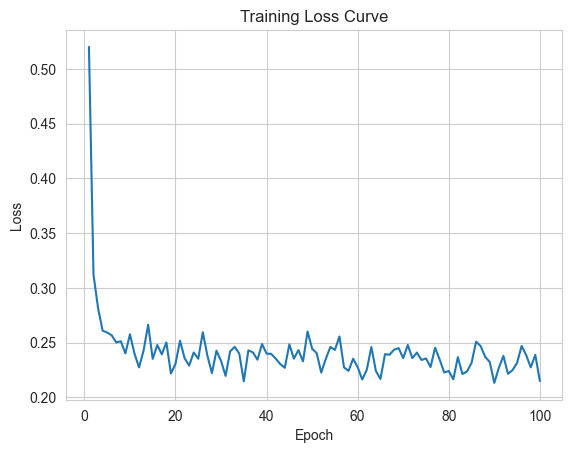

In [14]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

# 6. Evaluate Model

In [15]:
from sklearn.metrics import r2_score, mean_squared_error

def evaluate_accuracy():
    model.eval()
    
    train_total = 0
    train_corrected = 0
    
    with torch.no_grad():
        for batch_features, batch_labels in train_dataloader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            y_pred =  model(batch_features)
            _, predicted = torch.max(y_pred, 1)
        
            train_total += batch_features.size(0)
            train_corrected += (predicted == batch_labels).sum().item()
            
    train_accuracy = 100 * train_corrected / train_total
    
    test_total = 0
    test_corrected = 0
    
    with torch.no_grad():
        for batch_features, batch_labels in test_dataloader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            y_pred =  model(batch_features)
            _, predicted = torch.max(y_pred, 1)
        
            test_total += batch_features.size(0)
            test_corrected += (predicted == batch_labels).sum().item()
            
    test_accuracy = 100 * test_corrected / test_total
    
    return {
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
    }

In [16]:
evaluate_accuracy()

{'Train Accuracy': 95.4, 'Test Accuracy': 94.65}

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def evaluate_confusion_matrix():
    model.eval()
    
    all_predicts = []
    all_labels = []
    
    with torch.no_grad():
        for batch_features, batch_labels in test_dataloader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            y_pred =  model(batch_features)
            _, predicted = torch.max(y_pred, 1)
        
            all_predicts.extend(predicted.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_predicts)
    
    labels = lb.classes_
    plt.figure(figsize=(8,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

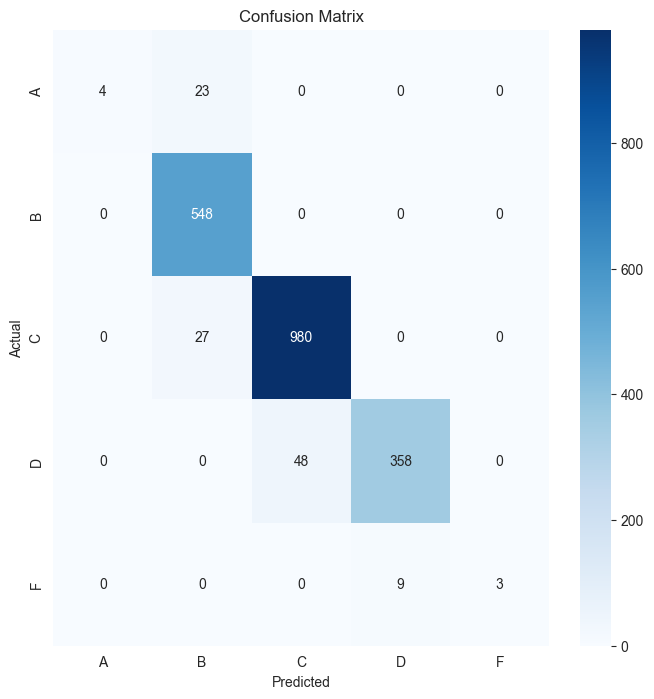

In [18]:
evaluate_confusion_matrix()